# Análise de Indicadores — Databurgo Brasil Tecnologia
## Projeto Integrador V-A | PUC Goiás

Este notebook documenta, passo a passo, os cálculos que sustentam os
indicadores apresentados no relatório técnico (seção 8 — Principais Análises
Realizadas) e no dashboard interativo (`app_diagnostico.py`).

Ele **não substitui** o dashboard — o dashboard é a peça interativa de apoio
à decisão (entregável 3.2); este notebook é uma peça complementar que expõe
o raciocínio de cálculo de forma aberta e comentada, útil para conferência
e para quem quiser entender a lógica sem precisar ler o código do app linha
a linha.

Trabalha apenas com números agregados fornecidos pela organização parceira —
nenhum dado individual de cliente é utilizado ou simulado.

## 1. Carregamento dos dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Base de benchmarks de mercado (mesma usada pelo app_diagnostico.py)
benchmarks = pd.read_csv("benchmarks_mercado.csv")
benchmarks

,indicador,segmento,valor_min,valor_max,unidade,classificacao_faixa,fonte,observacao
0,Churn mensal,Pequenas empresas de tecnologia / agencias dig...,3.0,5.0,% ao mes,saudavel,INBLOG.AI - Churn Rate benchmarks de SaaS (htt...,Abaixo de 1% e classe mundial; 1-3% e excelent...
1,Churn mensal,Pequenas empresas de tecnologia / agencias dig...,0.0,3.0,% ao mes,excelente,KIVOPOST - What is Churn Rate (https://kivopos...,Churn mensal abaixo de 3% e considerado forte ...
2,Churn mensal,Pequenas empresas de tecnologia / agencias dig...,5.0,7.0,% ao mes,atencao,GURUSUP - Calculadora de Churn Rate (https://g...,Empresa SaaS media perde 5-7% de clientes ao mes
3,Cross-sell,Pequenas empresas de servicos de tecnologia,20.0,40.0,% da base com mais de um servico,linha_base_interna,Nao ha benchmark publico consolidado para o se...,Sem fonte de mercado consolidada; usar como li...
4,Satisfacao percebida (CSAT 0-10),Servicos B2B em geral,7.5,8.5,nota de 0 a 10,referencia_qualitativa,QUESTIONPRO - Benchmarks de NPS para industria...,Metodologia de NPS (-100 a 100) nao e diretame...


## 2. Dados agregados fornecidos pela Databurgo (mar–ago/2026)

Números repassados diretamente pelo representante da organização parceira
(Brendo Oliveira Marinho), conforme descrito na seção 3 do relatório técnico.

In [2]:
clientes_inicio = 38      # clientes ativos em 01/03/2026
clientes_fim = 46         # clientes ativos em 31/08/2026
cancelamentos = 5         # cancelamentos no período
meses_periodo = 6         # duração do período em meses
mrr = 19750.0             # Receita Recorrente Mensal (R$), ponto médio informado
clientes_cross_sell = 14  # clientes com mais de um serviço contratado
satisfacao = 8.7          # autoavaliação do fundador, escala 0-10 (ponto médio 8,5-9,0)

print(f"Clientes: {clientes_inicio} -> {clientes_fim}")
print(f"Cancelamentos no período: {cancelamentos}")
print(f"MRR: R$ {mrr:,.2f}")

Clientes: 38 -> 46
Cancelamentos no período: 5
MRR: R$ 19,750.00


## 3. Cálculo do churn mensal equivalente

O churn informado pela empresa é acumulado ao longo de 6 meses. Para comparar
com benchmarks de mercado — que normalmente são expressos em base **mensal** —
é preciso converter o acumulado em uma taxa mensal equivalente.

Fórmula utilizada (juros compostos "reversos"):

$$\text{churn\_mensal} = 1 - (1 - \text{churn\_acumulado})^{\frac{1}{n\_meses}}$$

In [3]:
churn_acumulado = cancelamentos / clientes_inicio
churn_mensal = 1 - (1 - churn_acumulado) ** (1 / meses_periodo)

print(f"Churn acumulado no período: {churn_acumulado*100:.2f}%")
print(f"Churn mensal equivalente: {churn_mensal*100:.2f}% ao mês")

Churn acumulado no período: 13.16%
Churn mensal equivalente: 2.32% ao mês


## 4. Ticket médio por cliente e taxa de cross-sell

In [4]:
ticket_medio = mrr / clientes_fim
cross_sell_pct = clientes_cross_sell / clientes_fim * 100

print(f"Ticket médio por cliente: R$ {ticket_medio:,.2f}")
print(f"Taxa de cross-sell: {cross_sell_pct:.1f}% da base")

Ticket médio por cliente: R$ 429.35
Taxa de cross-sell: 30.4% da base


## 5. Comparação com benchmarks de mercado

Para cada indicador com benchmark disponível, comparamos o valor calculado
com a faixa de mercado carregada em `benchmarks_mercado.csv`.

In [5]:
def faixa(indicador):
    linha = benchmarks[benchmarks["indicador"] == indicador]
    return linha.iloc[0] if not linha.empty else None

faixa_churn = faixa("Churn mensal")
faixa_churn_saudavel = benchmarks[
    (benchmarks["indicador"] == "Churn mensal")
    & (benchmarks["classificacao_faixa"] == "saudavel")
].iloc[0]
faixa_cross = faixa("Cross-sell")

resumo = pd.DataFrame({
    "indicador": ["Churn mensal (%)", "Cross-sell (%)"],
    "valor_databurgo": [round(churn_mensal * 100, 2), round(cross_sell_pct, 1)],
    "benchmark_min": [faixa_churn_saudavel["valor_min"], faixa_cross["valor_min"]],
    "benchmark_max": [faixa_churn_saudavel["valor_max"], faixa_cross["valor_max"]],
})
resumo

,indicador,valor_databurgo,benchmark_min,benchmark_max
0,Churn mensal (%),2.32,3.0,5.0
1,Cross-sell (%),30.40,20.0,40.0


## 6. Visualização comparativa (Matplotlib)

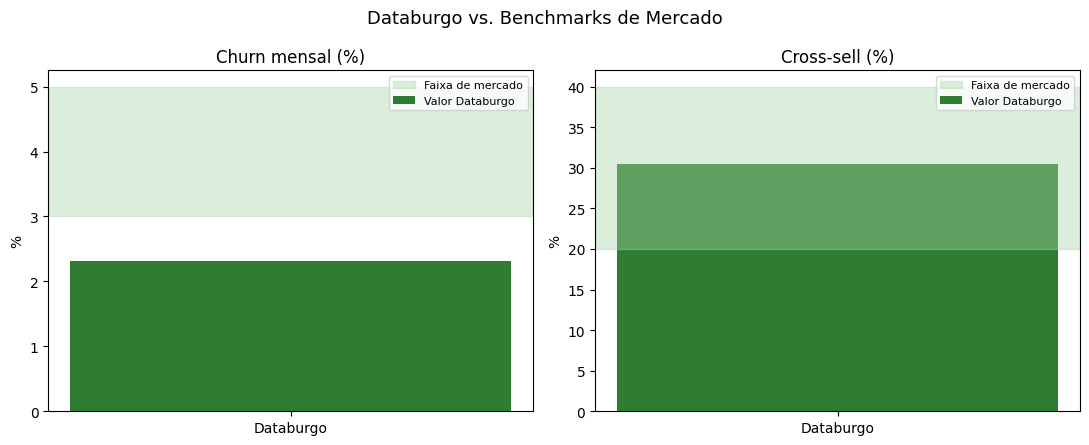

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (_, row) in zip(axes, resumo.iterrows()):
    cor = "#2E7D32" if row["benchmark_min"] <= row["valor_databurgo"] <= row["benchmark_max"] or row["valor_databurgo"] < row["benchmark_min"] else "#C62828"
    ax.bar(["Databurgo"], [row["valor_databurgo"]], color=cor, width=0.4, label="Valor Databurgo")
    ax.axhspan(row["benchmark_min"], row["benchmark_max"], color="#A5D6A7", alpha=0.4, label="Faixa de mercado")
    ax.set_title(row["indicador"])
    ax.set_ylabel("%")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Databurgo vs. Benchmarks de Mercado", fontsize=13)
plt.tight_layout()
plt.savefig("comparativo_benchmarks.png", dpi=120)
plt.show()

## 7. Síntese dos resultados

- **Churn mensal (≈2,32%)**: dentro — na verdade, melhor do que — a faixa que
  o mercado considera saudável para pequenas empresas de tecnologia (3% a 5%
  ao mês). Confirma, com evidência objetiva, a percepção que o fundador já
  tinha de que a retenção de clientes é boa.
- **Ticket médio (≈R$ 429,35)**: usado como referência interna de
  acompanhamento financeiro, sem benchmark externo comparável.
- **Cross-sell (≈30,4%)**: dentro da linha de base interna de referência
  (20% a 40%), mas ainda deixando margem de crescimento — cerca de 70% da
  base contrata apenas um serviço, o que aponta uma oportunidade comercial
  sem necessidade de captar clientes novos.
- **Satisfação percebida (8,7/10)**: tratada apenas como referência
  qualitativa de contexto, por ser uma autoavaliação do fundador e não uma
  pesquisa formal aplicada aos clientes da Databurgo.

Estes mesmos números e leituras estão refletidos no relatório técnico
(seções 8 e 10) e no dashboard interativo `app_diagnostico.py`.